In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/quora-question-pairs/train.csv.zip
/kaggle/input/competitions/quora-question-pairs/sample_submission.csv.zip
/kaggle/input/competitions/quora-question-pairs/test.csv
/kaggle/input/competitions/quora-question-pairs/test.csv.zip


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [4]:
df=pd.read_csv("/kaggle/input/competitions/quora-question-pairs/train.csv.zip")

In [5]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [6]:
df.shape

(404290, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [8]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
339526,339526,415280,461003,What is your meaning of the universe?,What is the meaning of the universe?,1
28988,28988,53684,53685,What is engineering management?,What is engineering managment?,1
183323,183323,280371,26961,How do you develop your personality?,How do develop my personality?,0
93858,93858,156838,156839,How do I get investor for application?,How can I get investors?,0
237983,237983,105172,168404,What do you think of Bob Dylan being awarded t...,What is your view on Bob Dylan winning Nobel p...,1


In [9]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['is_duplicate'].value_counts()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [12]:
(df['is_duplicate'].value_counts())/(df['is_duplicate'].count()) *100

is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64

<Axes: xlabel='is_duplicate'>

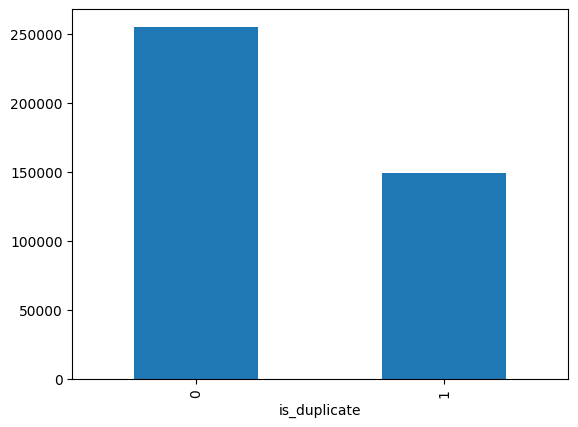

In [13]:
df['is_duplicate'].value_counts().plot(kind="bar")

In [14]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print("Number of unique questions:",np.unique(qid).shape[0])
x=qid.value_counts()>1
print("number of duplicated questions",x[x].shape[0])

Number of unique questions: 537933
number of duplicated questions 111780


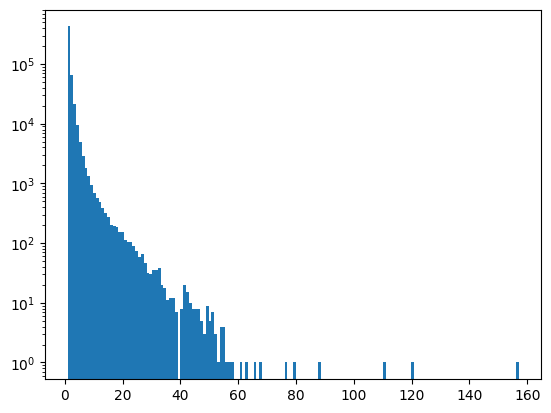

In [15]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')

# Simplest Approach

In [16]:
new_df=df.sample(30000)

In [17]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [18]:
new_df.duplicated().sum()

np.int64(0)

In [19]:
ques_df=new_df[['question1','question2']]

In [20]:
ques_df.head()

,question1,question2
41925,When did you have your first orgasm?,When was your first orgasm and how?
276100,Is it too late for a thirty year old to start ...,Is it too late for a 30 year old to learn danc...
148161,Why do many female porn stars have long finger...,How often do porn stars actually have an orgas...
47642,Is mumbai settled girl really not good for mar...,Where can I lodge a compliant regarding online...
46009,What are some great examples of content market...,What is the best example of content marketing?


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

questions=(ques_df['question1']).tolist()+(ques_df['question2']).tolist()
cv=CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [22]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [23]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
41925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
276100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
148161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47642,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
46009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
temp_df['is_duplicate']=new_df['is_duplicate']

In [25]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
41925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
276100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
148161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47642,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
46009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [27]:
X_train.shape,X_test.shape

((24000, 6000), (6000, 6000))

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7388333333333333

In [29]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7231666666666666

# Feature extraction

In [31]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()

In [32]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
41925,41925,75625,75626,When did you have your first orgasm?,When was your first orgasm and how?,1,36,35
276100,276100,395002,395003,Is it too late for a thirty year old to start ...,Is it too late for a 30 year old to learn danc...,0,63,50
148161,148161,233670,209801,Why do many female porn stars have long finger...,How often do porn stars actually have an orgas...,0,52,58
47642,47642,85032,85033,Is mumbai settled girl really not good for mar...,Where can I lodge a compliant regarding online...,0,90,56
46009,46009,82352,82353,What are some great examples of content market...,What is the best example of content marketing?,1,50,46


In [33]:
new_df['q1_num_wwords']=new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_wwords']=new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords
41925,41925,75625,75626,When did you have your first orgasm?,When was your first orgasm and how?,1,36,35,7,7
276100,276100,395002,395003,Is it too late for a thirty year old to start ...,Is it too late for a 30 year old to learn danc...,0,63,50,14,12
148161,148161,233670,209801,Why do many female porn stars have long finger...,How often do porn stars actually have an orgas...,0,52,58,9,11
47642,47642,85032,85033,Is mumbai settled girl really not good for mar...,Where can I lodge a compliant regarding online...,0,90,56,17,9
46009,46009,82352,82353,What are some great examples of content market...,What is the best example of content marketing?,1,50,46,8,8


In [34]:
def common_words(row):
    w1=set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [35]:
new_df['word_common']=new_df.apply(common_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common
41925,41925,75625,75626,When did you have your first orgasm?,When was your first orgasm and how?,1,36,35,7,7,3
276100,276100,395002,395003,Is it too late for a thirty year old to start ...,Is it too late for a 30 year old to learn danc...,0,63,50,14,12,9
148161,148161,233670,209801,Why do many female porn stars have long finger...,How often do porn stars actually have an orgas...,0,52,58,9,11,4
47642,47642,85032,85033,Is mumbai settled girl really not good for mar...,Where can I lodge a compliant regarding online...,0,90,56,17,9,0
46009,46009,82352,82353,What are some great examples of content market...,What is the best example of content marketing?,1,50,46,8,8,4


In [38]:
def total_words(row):
    w1=set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(),row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [39]:
new_df['total_words']=new_df.apply(total_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words
41925,41925,75625,75626,When did you have your first orgasm?,When was your first orgasm and how?,1,36,35,7,7,3,14
276100,276100,395002,395003,Is it too late for a thirty year old to start ...,Is it too late for a 30 year old to learn danc...,0,63,50,14,12,9,25
148161,148161,233670,209801,Why do many female porn stars have long finger...,How often do porn stars actually have an orgas...,0,52,58,9,11,4,20
47642,47642,85032,85033,Is mumbai settled girl really not good for mar...,Where can I lodge a compliant regarding online...,0,90,56,17,9,0,23
46009,46009,82352,82353,What are some great examples of content market...,What is the best example of content marketing?,1,50,46,8,8,4,16


In [40]:
new_df['word_share']=round(new_df['word_common']/new_df['total_words'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share
41925,41925,75625,75626,When did you have your first orgasm?,When was your first orgasm and how?,1,36,35,7,7,3,14,0.21
276100,276100,395002,395003,Is it too late for a thirty year old to start ...,Is it too late for a 30 year old to learn danc...,0,63,50,14,12,9,25,0.36
148161,148161,233670,209801,Why do many female porn stars have long finger...,How often do porn stars actually have an orgas...,0,52,58,9,11,4,20,0.20
47642,47642,85032,85033,Is mumbai settled girl really not good for mar...,Where can I lodge a compliant regarding online...,0,90,56,17,9,0,23,0.00
46009,46009,82352,82353,What are some great examples of content market...,What is the best example of content marketing?,1,50,46,8,8,4,16,0.25
